In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.utils.dataframe_utils import create_dataframe

df_train_seg = create_dataframe(
    "../data/train.csv", 
    "../data/boneage-training-segmented-gray", 
    segmented=True)

df_test = create_dataframe(
    "../data/test.csv",
    "../data/boneage-test-dataset", 
    segmented=False)

df_test_seg = create_dataframe(
    "../data/test.csv",
    "../data/boneage-test-segmented-gray", 
    segmented=True)

In [3]:
m = df_train_seg["boneage"].mean() # Mean label training
s = df_train_seg["boneage"].std()

In [4]:
from src.preprocessing.scaling import scaling_data_torch

df_train_seg, df_test, df_test_seg, scaler_seg = scaling_data_torch(df_train_seg, df_test, df_test_seg)

In [5]:
from src.preprocessing.datasets import BoneAgeDataset
from src.preprocessing.transforms import transform

test_dataset = BoneAgeDataset(df_test, transform=transform)
test_seg_dataset = BoneAgeDataset(df_test_seg, transform=transform)

In [6]:
from torch.utils.data import DataLoader

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

test_seg_loader = DataLoader(
    test_seg_dataset,
    batch_size=32,
    shuffle=False
)

In [7]:
from src.model.cnn_torch import BoneAgeModel

In [8]:
import torch
device = torch.device("cuda")

model = BoneAgeModel().to(device)
model.load_state_dict(torch.load("model_results/torch_model.pt", map_location=device))


C:\Users\silvi\AppData\Local\Temp\ipykernel_30528\3473990909.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model_results/torch_model.

<All keys matched successfully>

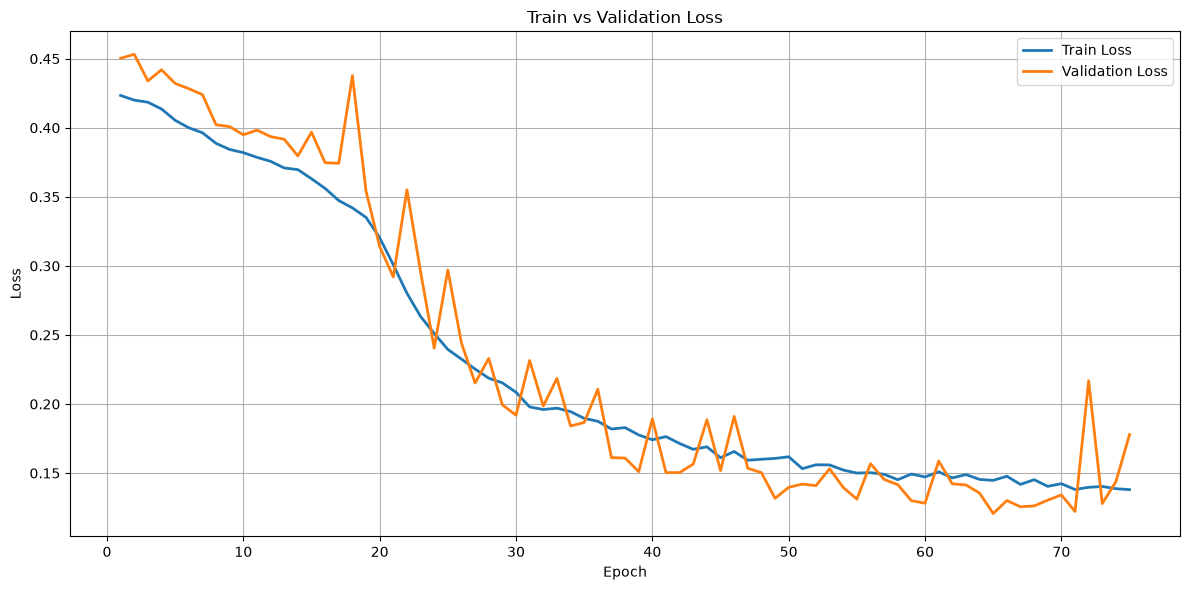

In [9]:
from src.visualization.plots import plot_loss

plot_loss("model_results/training_history_torch.xlsx")

In [10]:
import numpy as np
import torch

y_true = []
y_pred_seg = []
y_pred = []

model.eval()

with torch.no_grad():
    for batch in test_seg_loader:

        image = batch["image"].to(device)
        y = batch["boneage"].to(device)

        pred_seg = model(image)

        y_true.append(y.cpu().numpy())
        y_pred_seg.append(pred_seg.cpu().numpy())

with torch.no_grad():
    for batch in test_loader:

        image = batch["image"].to(device)

        pred = model(image)

        y_pred.append(pred.cpu().numpy())



y_true = np.concatenate(y_true)
y_pred_seg = np.concatenate(y_pred_seg)
y_pred = np.concatenate(y_pred)

In [11]:
y_true = s * y_true + m
y_pred_seg = s * y_pred_seg + m
y_pred = s * y_pred + m



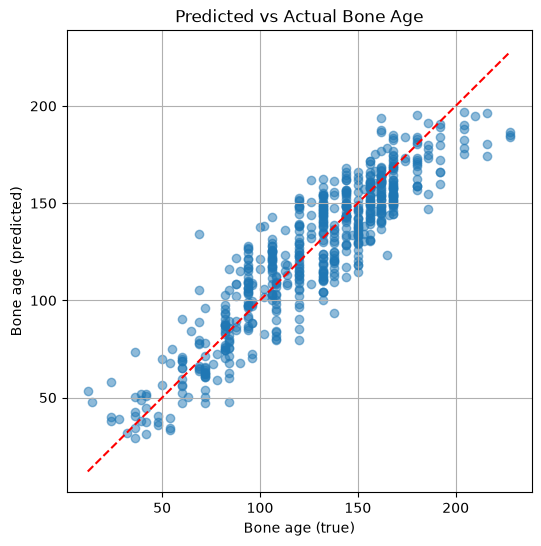

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_true, y_pred_seg, alpha=0.5)

plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    'r--'
)

plt.xlabel("Bone age (true)")
plt.ylabel("Bone age (predicted)")
plt.title("Predicted vs Actual Bone Age")

plt.grid(True)
plt.show()

In [13]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae = mean_absolute_error(y_true, y_pred_seg)
rmse = root_mean_squared_error(y_true, y_pred_seg)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 13.0724588454724
RMSE: 16.22872199049844


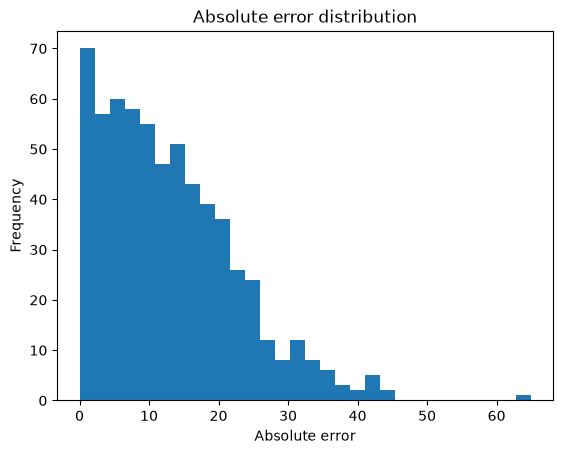

In [14]:
import numpy as np

errors = np.abs(y_true - y_pred_seg)

plt.hist(errors, bins=30)
plt.xlabel("Absolute error")
plt.ylabel("Frequency")
plt.title("Absolute error distribution")
plt.show()

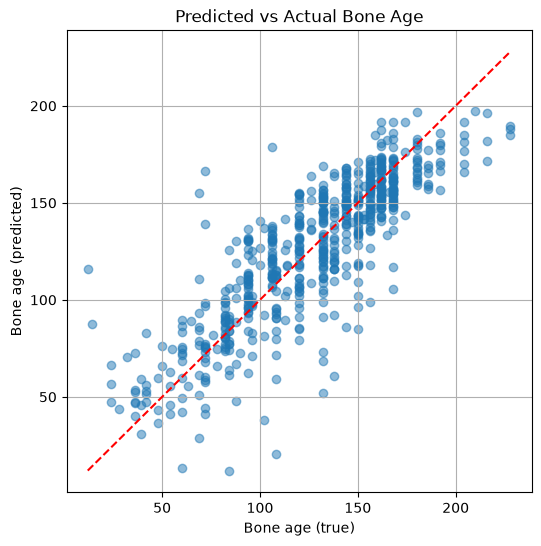

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_true, y_pred, alpha=0.5)

plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    'r--'
)

plt.xlabel("Bone age (true)")
plt.ylabel("Bone age (predicted)")
plt.title("Predicted vs Actual Bone Age")

plt.grid(True)
plt.show()

In [16]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 16.179516995222418
RMSE: 21.636904470893516


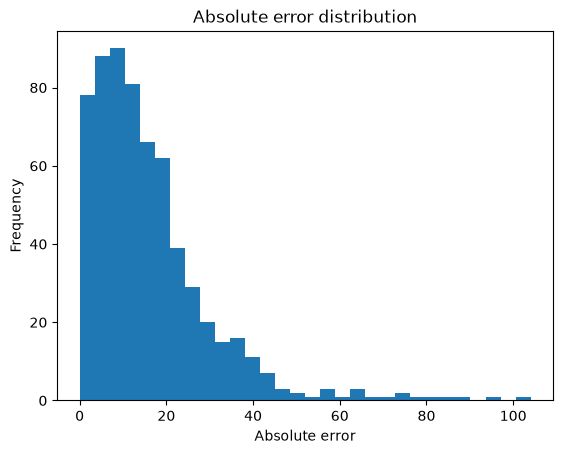

In [17]:
import numpy as np

errors = np.abs(y_true - y_pred)

plt.hist(errors, bins=30)
plt.xlabel("Absolute error")
plt.ylabel("Frequency")
plt.title("Absolute error distribution")
plt.show()